Libraries imported successfully
Data shape: (101766, 71)
Target distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64
Using dataset with shape: (101766, 71)
Training set: (81412, 70), Test set: (20354, 70)
Training models...
Training logistic...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


  File "c:\Users\dinne\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\dinne\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\dinne\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\dinne\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Best logistic Recall: 0.5248
Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
CV Precision: 0.1614
CV F1: 0.2468
CV AUC: 0.6295
--------------------------------------------------
Training random_forest...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best random_forest Recall: 0.1960
Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 100}
CV Precision: 0.2011
CV F1: 0.1985
CV AUC: 0.6341
--------------------------------------------------
Training xgboost...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best xgboost Recall: 0.8774
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 7.960158485582214}
CV Precision: 0.1273
CV F1: 0.2224
CV AUC: 0.6420
--------------------------------------------------
Evaluating models...
LOGISTIC       
  AUC: 0.6426
  F1: 0.2555
  Recall: 0.54

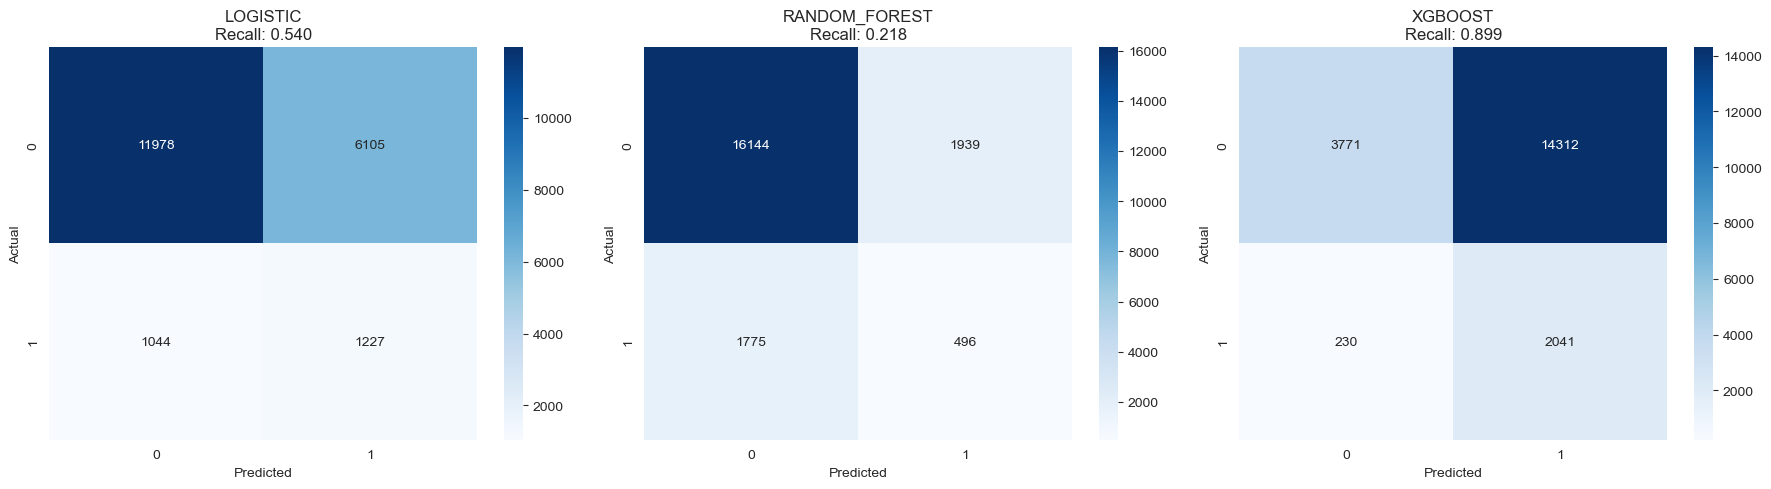

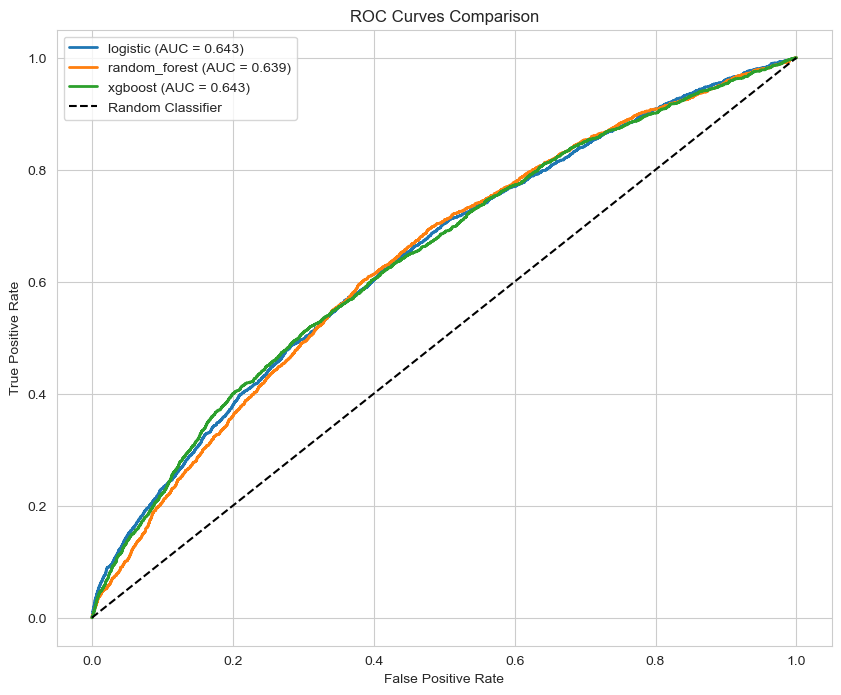

Training and evaluation completed successfully


In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score, fbeta_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

# Set up visual settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
file_path = r"C:\Users\dinne\Diabetic-Readmissions-\Data\Processed\cleaned_diabetic_data.csv"
df = pd.read_csv(file_path)
print(f"Data shape: {df.shape}")
print(f"Target distribution:\n{df['readmitted'].value_counts()}")

# Use the dataset as-is
df_enhanced = df.copy()
print(f"Using dataset with shape: {df_enhanced.shape}")

# Split data
X = df_enhanced.drop('readmitted', axis=1)
y = df_enhanced['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Custom scoring - Focus on recall
custom_scorers = {
    'recall': make_scorer(recall_score, pos_label=1),  # Primary metric
    'precision': make_scorer(precision_score, pos_label=1),
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Three core models with SMOTE
pipelines = {
    'logistic': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'random_forest': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'xgboost': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
    ])
}

# Simplified parameter grids for faster training
param_grids = {
    'logistic': {
        'classifier__C': [0.1, 1],
        'classifier__class_weight': ['balanced']
    },
    'random_forest': {
        'classifier__n_estimators': [100],
        'classifier__max_depth': [10, None],
        'classifier__class_weight': ['balanced']
    },
    'xgboost': {
        'classifier__n_estimators': [100],
        'classifier__max_depth': [3, 6],
        'classifier__learning_rate': [0.1],
        'classifier__scale_pos_weight': [len(y_train[y_train==0])/len(y_train[y_train==1])]
    }
}

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Train models
trained_models = {}
print("Training models...")

for name, pipeline in pipelines.items():
    print(f"Training {name}...")
    
    grid = GridSearchCV(
        pipeline, 
        param_grids[name], 
        cv=cv, 
        scoring=custom_scorers,
        refit='recall',
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    trained_models[name] = grid.best_estimator_
    print(f"Best {name} Recall: {grid.best_score_:.4f}")
    print(f"Best parameters: {grid.best_params_}")
    
    # Show all metrics for the best model
    best_index = grid.best_index_
    print(f"CV Precision: {grid.cv_results_['mean_test_precision'][best_index]:.4f}")
    print(f"CV F1: {grid.cv_results_['mean_test_f1'][best_index]:.4f}")
    print(f"CV AUC: {grid.cv_results_['mean_test_roc_auc'][best_index]:.4f}")
    print("-" * 50)

# Evaluate models
print("Evaluating models...")
print("=" * 60)

test_results = {}

for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    test_results[name] = {
        'auc': roc_auc_score(y_test, y_pred_proba),
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred)
    }
    
    print(f"{name.upper():<15}")
    print(f"  AUC: {test_results[name]['auc']:.4f}")
    print(f"  F1: {test_results[name]['f1']:.4f}")
    print(f"  Recall: {test_results[name]['recall']:.4f}")
    print(f"  Precision: {test_results[name]['precision']:.4f}")
    print(f"  Accuracy: {test_results[name]['accuracy']:.4f}")
    print("-" * 30)

# Performance comparison
print("PERFORMANCE SUMMARY")
print("=" * 60)

summary_data = []
for name, metrics in test_results.items():
    summary_data.append({
        'Model': name,
        'AUC': f"{metrics['auc']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Accuracy': f"{metrics['accuracy']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Find best model by recall
best_model_name = max(test_results, key=lambda x: test_results[x]['recall'])
print(f"\nBest model for recall: {best_model_name.upper()}")
print(f"Recall: {test_results[best_model_name]['recall']:.4f}")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name.upper()}\nRecall: {test_results[name]["recall"]:.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

print("Training and evaluation completed successfully")